# Manual Implementation of Deep Learning

[Use numpy for all questions]

In [1]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

## Linear Regression
**We will do a linear regression using backpropagartion.**
*Of course, there is an analyctical solution to this problem, but the techniques used can be generalized to complex models (like actual neural networks), for which we do not have an analyctical solution to compute the optimal weights.* We forget about activation functions for now because we do not need non-linearity (we are trying to fit a linear function!).

Create $N \in \mathbb{N}$ points of data $x_i, 0 \leq i < N$ with $x_i \in [0,1)$ and associated (noised) output $y_i = a*x_i+b+\epsilon_i$ with $\epsilon_i \approx \mathcal{N}(0,0.01)$. Use the function `np.random.randn`.

Use $a=2$, $b=1$ & $N=100$

In [2]:
N = 100
true_a = 2
true_b = 1
eps = 0.1
x = np.random.uniform(0, 1, N)
y = true_a*x + true_b + np.random.randn(N)*eps

Plot the dots to check it makes sense to use a linear model

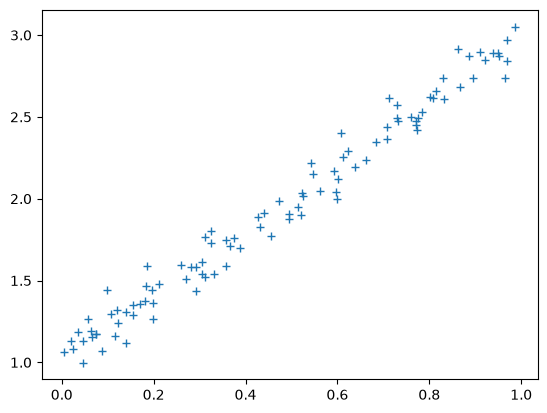

In [3]:
plt.plot(x,y, '+')

Initialize parameters $a$ and $b$ randomly (this is our first guess of a and b, obviously wrong, but we need to initialize them to start the training converging to the right values).

In [4]:
a = np.random.randn()
b = np.random.randn()


Calculate your predictions $\hat{y} = a * x_{train} +b$

In [5]:
yhat = a*x + b

Calculate the error $err = \hat{y} - y_{train}$ and the MSE loss defined as:

$loss = \frac{err^2}{N}$ (dividing by $N$ is not actually necessary)

In [6]:
err = yhat-y
loss = sum(err**2) / N

Compute the gradients for both the $a$ and $b$ parameters

In [7]:
a_grad = 2 * sum(x*err) / N
b_grad = 2 * sum(err) / N

Update parameters using gradients and the learning rate `lr = 1e-1`

In [8]:
lr = 0.1
a = a-lr*a_grad
b = b-lr*b_grad


Repeat this for $1000$ epochs and plot error as a function of epoch

In [9]:
a = np.random.randn()
b = np.random.randn()
for _ in range(1000):
    yhat = a*x + b
    err = yhat-y
    loss = sum(err**2) / N
    a_grad = 2 * sum(x*err) / N
    b_grad = 2 * sum(err) / N
    lr = 0.1
    a = a-lr*a_grad
    b = b-lr*b_grad
print(a, b)

1.9540211004317987 1.0215104136330815


Check that we get the same results as our gradient descent with an analytical linear regression (you may use `sklearn.linear_model.LinearRegression`)

In [10]:
import sklearn
import sklearn.linear_model

reg = sklearn.linear_model.LinearRegression()
reg.fit(x.reshape(N,1),y.reshape(N,1))
reg.coef_, reg.intercept_

(array([[1.95402268]]), array([1.02150962]))

-----

## $XOR$
**We will create a (simple) neural network with 2 layers to fit the $XOR$ function.**

*Of course, this is dumb since the xor function is (much) faster than running a neural network; but the technique can be used to fit complex functions, for which we may not even have an expression.*

You can try manually training a neural network to behave like an xor logical door with this interactive tool:
https://pauldubois98.github.io/TrainingAI/TrainNeuralNetwork.html


Other live challenges (with solutions) available here:
https://pauldubois98.github.io/TrainingAI/

Define the $XOR$ function and create some synthetic training data

In [ ]:
def xor(a,b):
    return not (a == b == 1 or a == b == 0)

xs = np.array([[0,0], [0,1], [1,0], [1,1]])
ys = np.array([[float(xor(a,b))] for a,b in xs])

xs,ys

(array([[0, 0],
        [0, 1],
        [1, 0],
        [1, 1]]),
 array([[0.],
        [1.],
        [1.],
        [0.]]))

Define the model's architecture and some hyperparameters:
- $10$ hidden units
- learning rate of $0.2$
- 10_000 epochs

In [12]:
# number of hidden units
n_hidden = 10
# learning rate
lr = 0.2
# number of epochs
n_epochs = 10_000

Define the model's weight matrices and biases.

Depending on how you perform the calculation between one layer and the other of the neural network ($l_{n} = Wl_{n-1} + b_n$ or $l_{n} = l_{n-1}W + b_n$), the number of rows and columns of W might be inverted.

In [13]:
w1 = np.random.randn(2, n_hidden)
b1 = np.random.randn(n_hidden)
w2 = np.random.randn(n_hidden, 1)
b2 = np.random.randn(1)

Define the sigmoid ($\forall x \in \mathbb{R} \: \sigma (x) = \frac{1}{1+e^{-x}}$) activation function and its derivative: 

$\forall x \in \mathbb{R} \:, \sigma'(x) =  \sigma (x) * (1-\sigma (x))$.

In [14]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

def dsigmoid(x):
    return sigmoid(x)*(1-sigmoid(x))

sigmoid(0), dsigmoid(0)

(np.float64(0.5), np.float64(0.25))

Define the forward pass of the model

In [15]:
def forward_pass(x):
    l1 = sigmoid(x @ w1 + b1)
    out = l1 @ w2 + b2
    return out

Test your model & plot its outputs

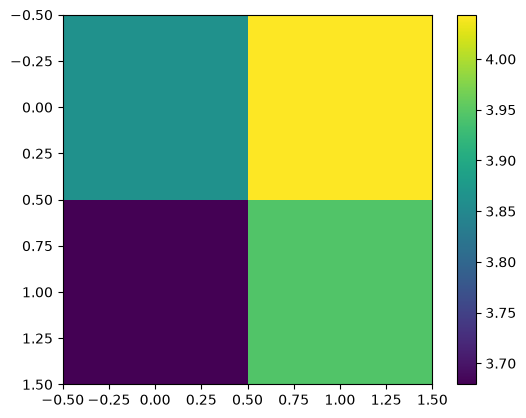

In [16]:
grid = forward_pass(xs)
plt.imshow(np.array(grid).reshape(2,2))
plt.colorbar()
plt.show()


Define the backward pass of the model

In [17]:
def backward_pass(xs, ys):
    N = len(xs)
    pre_l1 = xs @ w1 + b1
    l1 = sigmoid(pre_l1)
    out = l1 @ w2 + b2
    loss = sum((out-ys)**2)

    out_grad = 2 * (out-ys) / N
    w2_grad = l1.T @ out_grad
    b2_grad = out_grad.sum(axis=0)
    l1_grad = out_grad @ w2.T
    pre_l1_grad = l1_grad * dsigmoid(pre_l1)
    w1_grad = xs.T @ pre_l1_grad
    b1_grad = pre_l1_grad.sum(axis=0)
    return w1_grad, b1_grad, w2_grad, b2_grad, loss
            
backward_pass(xs, ys)

(array([[ 0.41361807,  0.89022724,  0.7838573 ,  0.44162252, -0.15597827,
          0.62277978, -0.58462986, -0.18258982, -0.3930298 ,  0.03760706],
        [ 0.47888029,  0.78953616,  0.70910945,  0.56002112, -0.18214   ,
          0.63954784, -0.66422852, -0.18777582, -0.40515399,  0.03609132]]),
 array([ 0.8974693 ,  1.66909073,  1.37683877,  0.92838188, -0.33907616,
         1.18702217, -1.21842692, -0.37049979, -0.78284086,  0.04811532]),
 array([[4.0836124 ],
        [4.28120059],
        [4.40938326],
        [4.35125714],
        [1.34634526],
        [2.76004026],
        [3.84517497],
        [4.30060149],
        [3.59426499],
        [6.05404241]]),
 array([6.76535234]),
 array([46.92645514]))

Performs the forward pass, backward pass, and weight updates for $10000$ epochs;
in addition:
- print the loss every $1000$ epochs
- save the losses and plot them in a semilogy

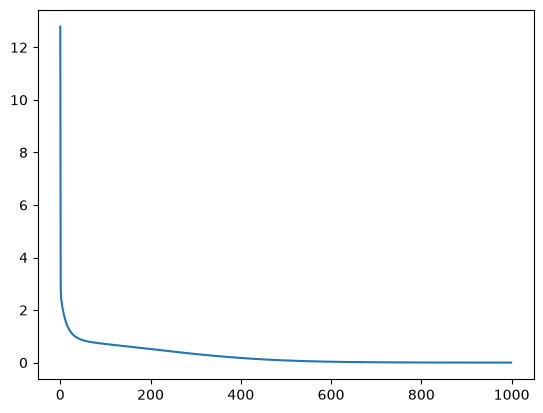

In [18]:
w1 = np.random.randn(2, n_hidden)
b1 = np.random.randn(n_hidden)
w2 = np.random.randn(n_hidden, 1)
b2 = np.random.randn(1)

lr = 0.1
losses = []
for _ in range(1000):
    w1_grad, b1_grad, w2_grad, b2_grad, loss= backward_pass(xs, ys)
    w1 = w1 - lr*w1_grad
    b1 = b1 - lr*b1_grad
    w2 = w2 - lr*w2_grad
    b2 = b2 - lr*b2_grad
    losses.append(loss)

plt.plot(losses)
plt.show()

Test your model & plot its outputs

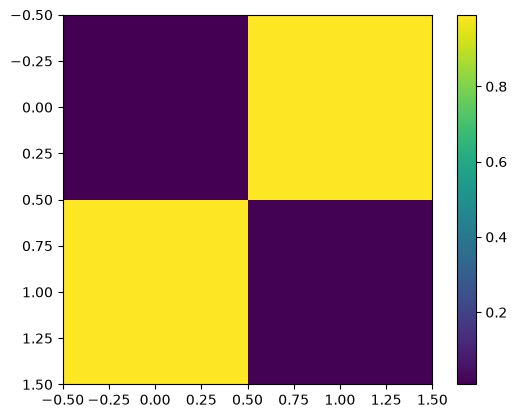

In [19]:
grid = forward_pass(xs)
plt.imshow(np.array(grid).reshape(2,2))
plt.colorbar()
plt.show()

Re-build your model using $ReLU$ activation instead of sigmoid (same number of hidden units, you may need to adjust the learning rate to $0.01$); which activation function converges the fastest?

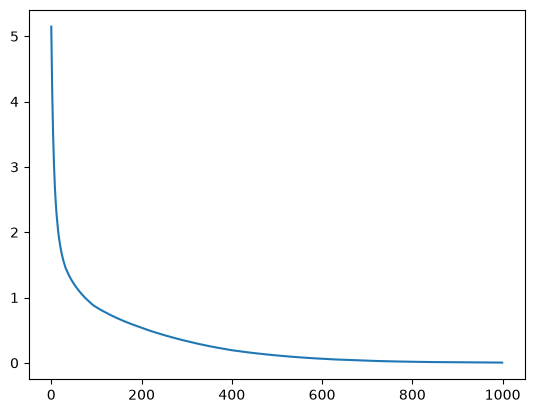

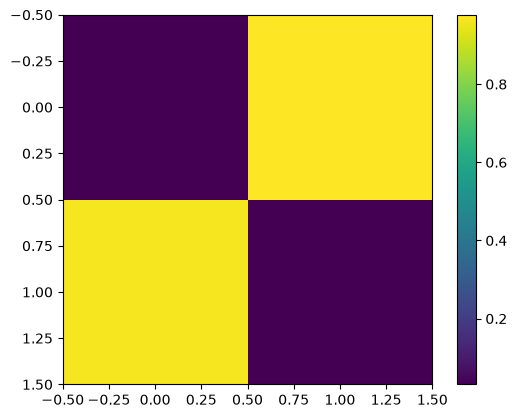

In [20]:
w1 = np.random.randn(2, n_hidden)
b1 = np.random.randn(n_hidden)
w2 = np.random.randn(n_hidden, 1)
b2 = np.random.randn(1)

def relu(x):
    return np.clip(x, 0, None)
def drelu(x):
    return x >= 0


def forward_pass(x):
    l1 = relu(x @ w1 + b1)
    out = l1 @ w2 + b2
    return out

def backward_pass(xs, ys):
    N = len(xs)
    pre_l1 = xs @ w1 + b1
    l1 = relu(pre_l1)
    out = l1 @ w2 + b2
    loss = sum((out-ys)**2)

    out_grad = 2 * (out-ys) / N
    w2_grad = l1.T @ out_grad
    b2_grad = out_grad.sum(axis=0)
    l1_grad = out_grad @ w2.T
    pre_l1_grad = l1_grad * drelu(pre_l1)
    w1_grad = xs.T @ pre_l1_grad
    b1_grad = pre_l1_grad.sum(axis=0)
    return w1_grad, b1_grad, w2_grad, b2_grad, loss

lr = 0.01
losses = []
for _ in range(1000):
    w1_grad, b1_grad, w2_grad, b2_grad, loss= backward_pass(xs, ys)
    w1 = w1 - lr*w1_grad
    b1 = b1 - lr*b1_grad
    w2 = w2 - lr*w2_grad
    b2 = b2 - lr*b2_grad
    losses.append(loss)

plt.plot(losses)
plt.show()

grid = forward_pass(xs)
plt.imshow(np.array(grid).reshape(2,2))
plt.colorbar()
plt.show()

If one activation function converges faster, does that mean it is better?

*Answer:*

Re-build your model using the identity activation function everywhere. What happens? Why does it make sense?

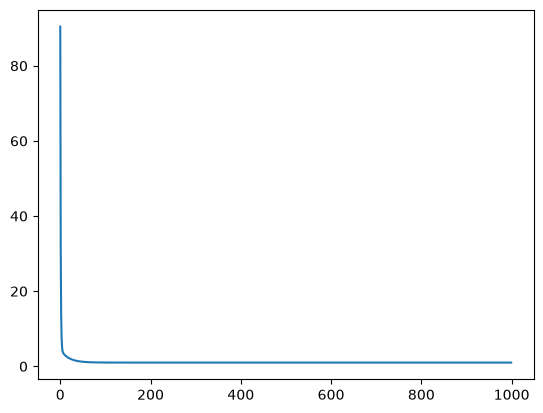

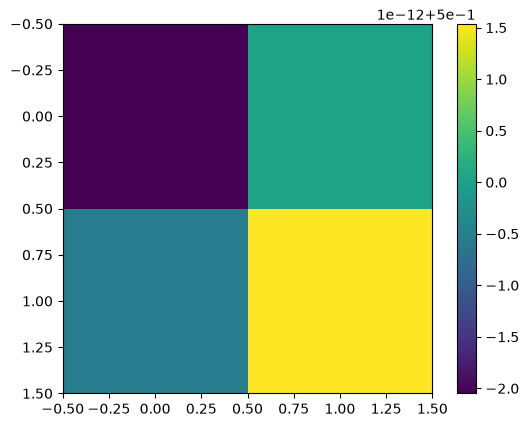

In [21]:
w1 = np.random.randn(2, n_hidden)
b1 = np.random.randn(n_hidden)
w2 = np.random.randn(n_hidden, 1)
b2 = np.random.randn(1)

def identity(x):
    return x
def didentity(x):
    return np.ones_like(x)


def forward_pass(x):
    l1 = identity(x @ w1 + b1)
    out = l1 @ w2 + b2
    return out

def backward_pass(xs, ys):
    N = len(xs)
    pre_l1 = xs @ w1 + b1
    l1 = identity(pre_l1)
    out = l1 @ w2 + b2
    loss = sum((out-ys)**2)

    out_grad = 2 * (out-ys) / N
    w2_grad = l1.T @ out_grad
    b2_grad = out_grad.sum(axis=0)
    l1_grad = out_grad @ w2.T
    pre_l1_grad = l1_grad * didentity(pre_l1)
    w1_grad = xs.T @ pre_l1_grad
    b1_grad = pre_l1_grad.sum(axis=0)
    return w1_grad, b1_grad, w2_grad, b2_grad, loss


lr = 0.01
losses = []
for _ in range(1000):
    w1_grad, b1_grad, w2_grad, b2_grad, loss= backward_pass(xs, ys)
    w1 = w1 - lr*w1_grad
    b1 = b1 - lr*b1_grad
    w2 = w2 - lr*w2_grad
    b2 = b2 - lr*b2_grad
    losses.append(loss)

plt.plot(losses)
plt.show()

grid = forward_pass(xs)
plt.imshow(np.array(grid).reshape(2,2))
plt.colorbar()
plt.show()

Create a network that has ReLU activation on the output as well as in the hidden layer. Try a few different seeds. What happens? Why?

*Hint: for a run that gets stuck, print the output layer's pre-activations and the gradients.*

seed 0: loss 2.000 -> 2.000, outputs = [0. 0. 0. 0.]
seed 1: loss 2.000 -> 2.000, outputs = [0. 0. 0. 0.]
seed 2: loss 27.563 -> 1.000, outputs = [0. 1. 0. 0.]
seed 3: loss 2.000 -> 2.000, outputs = [0. 0. 0. 0.]
seed 4: loss 1.434 -> 1.000, outputs = [0. 1. 0. 0.]
seed 5: loss 6.550 -> 0.000, outputs = [0. 1. 1. 0.]


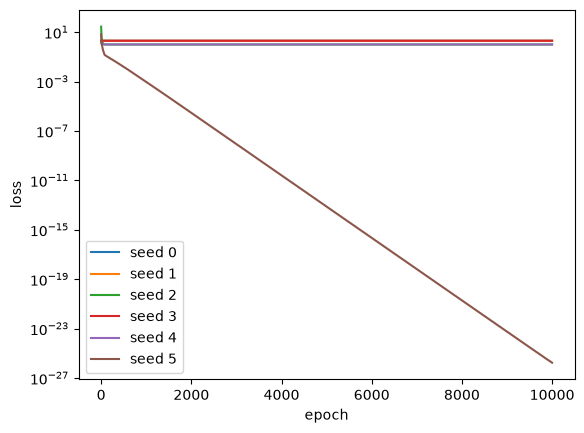

In [22]:
def relu(x):
    return np.clip(x, 0, None)
def drelu(x):
    return x >= 0


def forward_pass(x):
    l1 = relu(x @ w1 + b1)
    out = relu(l1 @ w2 + b2)
    return out

def backward_pass(xs, ys):
    N = len(xs)
    pre_l1 = xs @ w1 + b1
    l1 = relu(pre_l1)
    pre_out = l1 @ w2 + b2
    out = relu(pre_out)
    loss = np.sum((out-ys)**2)

    out_grad = 2 * (out-ys) / N * drelu(pre_out)
    w2_grad = l1.T @ out_grad
    b2_grad = out_grad.sum(axis=0)
    l1_grad = out_grad @ w2.T
    pre_l1_grad = l1_grad * drelu(pre_l1)
    w1_grad = xs.T @ pre_l1_grad
    b1_grad = pre_l1_grad.sum(axis=0)
    return w1_grad, b1_grad, w2_grad, b2_grad, loss


lr = 0.01
for seed in range(6):
    np.random.seed(seed)
    w1 = np.random.randn(2, n_hidden)
    b1 = np.random.randn(n_hidden)
    w2 = np.random.randn(n_hidden, 1)
    b2 = np.random.randn(1)

    losses = []
    for _ in range(10_000):
        w1_grad, b1_grad, w2_grad, b2_grad, loss = backward_pass(xs, ys)
        w1 = w1 - lr*w1_grad
        b1 = b1 - lr*b1_grad
        w2 = w2 - lr*w2_grad
        b2 = b2 - lr*b2_grad
        losses.append(loss)

    plt.semilogy(losses, label=f"seed {seed}")
    print(f"seed {seed}: loss {losses[0]:.3f} -> {losses[-1]:.3f}, outputs = {np.round(forward_pass(xs).ravel(), 2)}")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()


*Answer:*
- seeds $0$, $1$, $3$: the loss is stuck at exactly $2.0$ from the very first epoch to the last, and the network predicts $0$ for all four inputs;
- seeds $2$, $4$: the loss drops a little, then plateaus at $1.0$ (only one of the two $1$s is found);
- seed $5$: converges to $0$, the network learns $XOR$.

**Why?** Putting a $ReLU$ on the output adds one factor to every gradient: the derivative of that last activation, $relu'(pre\_out)$.
Since $relu'(x) = 0$ for $x<0$, any sample whose output pre-activation is negative contributes *nothing* to any gradient. 
So the error simply cannot flow back through a $ReLU$ that is off.
The parameters are a fixed point of gradient descent: they are never updated, and the loss stays frozen forever.

It is important to see that this is not slow convergence: the gradient is exactly $0$, not small.
Training longer will not help, and neither will changing the learning rate.
This is known as the "dying $ReLU$" problem, and it is also why the seed (i.e. the initialization) matters so much.